# Item Price Analysis Notebook
This notebook analyzes price distributions for various items in a bidding database.

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import widgets
from IPython.display import display, clear_output

In [36]:
# Connect to the SQLite database
# Create a sample database if it doesn't exist
try:
    conn = sqlite3.connect(r'C:\Users\dparks1\PycharmProjects\civilpy\Notebooks\output\ohio_bidtabs.db')
    cursor = conn.cursor()

    # Check if table exists
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='bid_values'")

except Exception as e:
    print(f"Database setup error: {e}")

In [48]:
def get_unique_items():
   """Retrieve unique item descriptions from the database."""
   query = "SELECT DISTINCT item_code FROM bid_values ORDER BY item_code"
   cursor.execute(query)
   items = [row[0] for row in cursor.fetchall()]
   return items

In [49]:
# Create dropdown widget for item selection
items = get_unique_items()
item_dropdown = widgets.Dropdown(
    options=items,
    description='Select Item:',
)

item_dropdown

Dropdown(description='Select Item:', options=('100E00300', '100E10000', '100E44000', '100E50000', '100E50100',…

In [45]:
# Function to plot the box and whisker chart for the selected item
def plot_item_prices(item_code):
    """Create a box and whisker plot for the selected item's price distribution"""
    # Query to get all prices for the selected item
    query = """
    SELECT bid_amount, contractor, quantity
    FROM bid_values
    WHERE item_code = ?
    ORDER BY bid_amount
    """

    # Execute query and load results into a DataFrame
    df = pd.read_sql_query(query, conn, params=(item_code,))

    if df.empty:
        print("No data available for this item.")
        return

    # Set up the figure
    plt.figure(figsize=(10, 6))

    # Create box plot
    sns.boxplot(y=df['bid_amount'])

    # Add a strip plot on top to show individual data points
    sns.stripplot(y=df['bid_amount'], color='black', alpha=0.5)

    # Add labels and title
    plt.title(f'Price Distribution for: {item_code}', fontsize=14)
    plt.ylabel('Price ($)', fontsize=12)

    # Add statistics
    stats_text = (
        f"Data Points: {len(df)}\n"
        f"Min: ${df['bid_amount'].min():.2f}\n"
        f"Max: ${df['bid_amount'].max():.2f}\n"
        f"Median: ${df['bid_amount'].median():.2f}\n"
        f"Mean: ${df['bid_amount'].mean():.2f}\n"
        f"Std Dev: ${df['bid_amount'].std():.2f}"
    )

    plt.figtext(0.02, 0.02, stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Display the price data
    print("\nPrice Data:")
    display_df = df.copy()
    display_df['bid_amount'] = display_df['bid_amount'].apply(lambda x: f"${x:.2f}")
    display_df.columns = ['bid_amount', 'Vendor', 'Quantity']
    display(display_df)

In [56]:
item_code = '516E41100'  # Used 1/8" CDP bearing as example item

query = """
SELECT bid_amount, contractor, quantity
FROM bid_values
WHERE item_code = ?
ORDER BY bid_amount
"""

# Execute query and load results into a DataFrame
df = pd.read_sql_query(query, conn, params=(item_code,))

In [58]:
df['unit_cost'] = df['bid_amount'] / df['quantity']

In [60]:
df['unit_cost'].max()

2976995.368

In [61]:
df['unit_cost'].min()

9846.969696969696

In [66]:
df['unit_cost']

0      1.545747e+04
1      5.175765e+04
2      2.110660e+04
3      2.183347e+04
4      2.276076e+04
           ...     
957    2.976995e+06
958    9.859607e+05
959    1.008937e+06
960    1.045357e+06
961    1.053304e+06
Name: unit_cost, Length: 962, dtype: float64

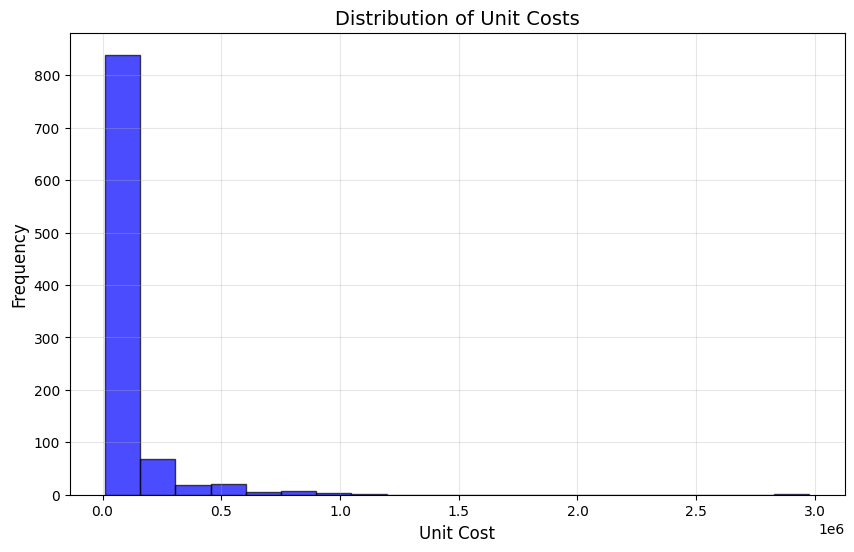

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['unit_cost'], bins=20, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Unit Costs', fontsize=14)
plt.xlabel('Unit Cost', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [67]:
from scipy.stats import zscore

# Compute Z-scores for the unit_cost column
df['z_score'] = zscore(df['unit_cost'])

# Filter data points within Z-score thresholds
df_no_outliers = df[(df['z_score'] > -3) & (df['z_score'] < 3)]
print(df_no_outliers)

      bid_amount                             contractor  quantity  \
0      185489.68            AXIS CIVIL CONSTRUCTION LLC      12.0   
1      207030.60                       VERNON NAGEL INC       4.0   
2      211066.00             BRUMBAUGH CONSTRUCTION INC      10.0   
3      218334.65                        EAGLE BRIDGE CO      10.0   
4      227607.65            AXIS CIVIL CONSTRUCTION LLC      10.0   
..           ...                                    ...       ...   
946   6974845.84            GREAT LAKES CONSTRUCTION CO      20.0   
953  10327322.88                        EAGLE BRIDGE CO      44.0   
954  11286424.10  COMPLETE GENERAL CONSTRUCTION COMPANY      44.0   
955  13029856.26                SUNESIS CONSTRUCTION CO      44.0   
956  17016026.49              BEAVER EXCAVATING COMPANY     440.0   

         unit_cost   z_score  
0     15457.473333 -0.458382  
1     51757.650000 -0.236307  
2     21106.600000 -0.423822  
3     21833.465000 -0.419375  
4     22760.7650

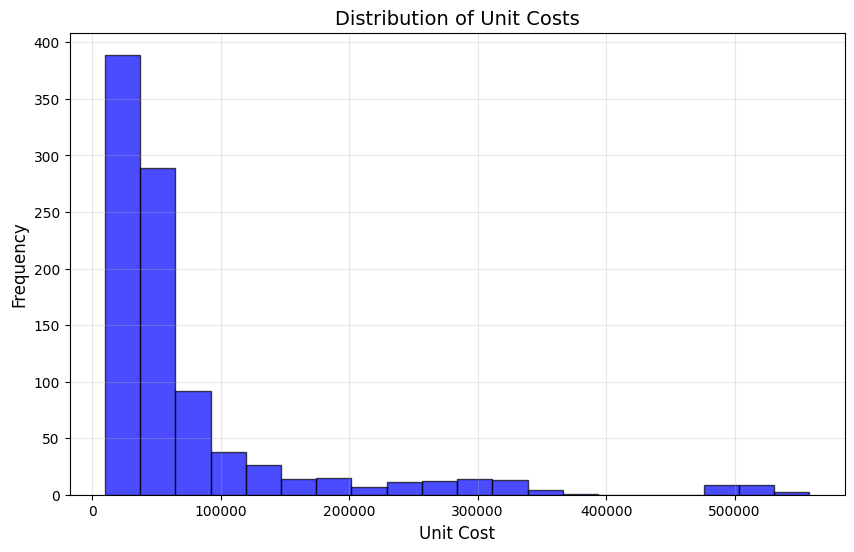

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_no_outliers['unit_cost'], bins=20, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Unit Costs', fontsize=14)
plt.xlabel('Unit Cost', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Dropdown(description='Select Item:', index=1440, options=('100E00300', '100E10000', '100E44000', '100E50000', …

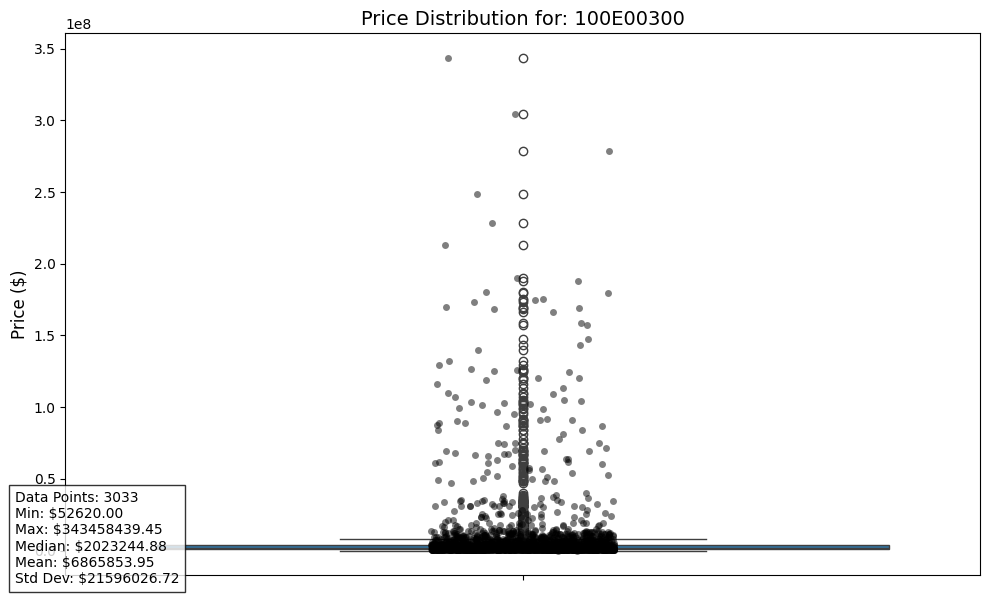


Price Data:


,bid_amount,Vendor,Quantity
0,$52620.00,SUBURBAN MAINTENANCE & CONSTRUCTION INC,1.0
1,$54295.00,A & A PAINTING LLC,1.0
2,$81784.36,COMPLETE GENERAL CONSTRUCTION COMPANY,1.0
3,$89000.00,MILLER CABLE COMPANY,1.0
4,$89930.00,PERRAM ELECTRIC INC,1.0
...,...,...,...
3028,$228076988.94,AMERICAN BRIDGE COMPANY,1.0
3029,$248815647.12,WALSH CONSTRUCTION COMPANY II LLC,1.0
3030,$278828509.18,KOKOSING CONSTRUCTION COMPANY INC,1.0
3031,$304147422.89,TRUMBULL-RUHLIN - A JOINT VENTURE,1.0


In [47]:
# Interactive widget with callback
def on_item_selected(change):
    """Callback when an item is selected from the dropdown"""
    clear_output(wait=True)
    display(item_dropdown)

    selected_item = change['new']
    if selected_item:
        plot_item_prices(selected_item)

# Register the callback
item_dropdown.observe(on_item_selected, names='value')

# Display the dropdown
display(item_dropdown)

# Plot the first item as default
if items:
    plot_item_prices(items[0])